In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")


import pandas as pd
import numpy as np


path="/kaggle/input/loan-approval-classification-data/loan_data.csv"

df = pd.read_csv(path,index_col=0)

display(df.head())


Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.


,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
person_age,,,,,,,,,,,,,
22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
import numpy as np


print("Primeras columnas del dataset:\n ")
display(df.head())

print("\nDimensiones del dataset: "+ str(df.shape)+"\n")
print("Las columnas tienen los nombres: \n"+ str(df.columns)+"\n")
print("Los tipos de datos son: \n"+ str(df.dtypes)+"\n")
print("Total de valores nulos por columna: \n"+ str(df.isnull().sum())+"\n")

print("\n\nMatriz de correlación original: \n")
display(df.select_dtypes(include=np.number).corr())

Primeras columnas del dataset:
 


,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
person_age,,,,,,,,,,,,,
22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1



Dimensiones del dataset: (45000, 13)

Las columnas tienen los nombres: 
Index(['person_gender', 'person_education', 'person_income', 'person_emp_exp',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

Los tipos de datos son: 
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

Total de valores nulos por co

,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_income,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numerical_cols = ['person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate',
                  'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
                    'loan_intent', 'previous_loan_defaults_on_file']

fl= RandomForestClassifier(n_jobs=-1, class_weight='balanced')

clf = LogisticRegression(max_iter=2000)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ])

x = df.drop(['loan_status'], axis=1)
y=df['loan_status'].values


x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y )


pl_RL = Pipeline([
    ('preprocesador', preprocessor),
    ('clasificador', clf)
])



pl_RL.fit(x_train,y_train)


pl_RF = Pipeline([
    ('preprocesador', preprocessor),
    ('clasificador', fl)
])

pl_RF.fit(x_train,y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['person_gender',
                                                   'person_education',
                                                   'person_home_ownership',
                                                   'loan_intent',
                                                   'previous_loan_defaults_on_file'])])),
                ('clasificador',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1))])

In [ ]:
pl = Pipeline([
    ('preprocesador', preprocessor),
    ('clasificador', clf)
])
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import pandas as pd



pl['preprocesador'].fit(x_train)

# Obtener las columnas generadas por el one hot encoding
x_train_processed = pl['preprocesador'].transform(x_train)
original_feature_names = pl['preprocesador'].get_feature_names_out(input_features=x.columns)



In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline





rfecv_pipeline_RL = Pipeline([
    ('preprocesador', preprocessor),
    ('feature_selection', RFECV(estimator=clf,
                                 step=1,
                                 cv=StratifiedKFold(5),
                                 scoring='accuracy',
                                 n_jobs=-1,
                                ))
])

#Ejecutar la eliminacion recursiva de caracteristicas usando cross validation
print("Empezando la elección de variables con RFECV")
rfecv_pipeline_RL.fit(x_train, y_train)
print("Seleccion de variables con RFECV completada")

# Obtener la mascara de las caracteristicas seleccionadas
selected_features_mask_RL = rfecv_pipeline_RL['feature_selection'].get_support()

#Seleccionar aquellas que si fueron elegidas por el algoritmo
selected_feature_names_rfecv_RL = [name for name, is_selected in zip(original_feature_names, selected_features_mask_RL) if is_selected]

print(f"Numero optimo de variables: {rfecv_pipeline_RL['feature_selection'].n_features_}")
print("Variables seleccionadas:")
display(selected_feature_names_rfecv_RL)


from sklearn.metrics import f1_score, classification_report

y_pred_rfecv_RL = rfecv_pipeline_RL.predict(x_test)

print("\nClassification Report con las variables seleccionadas por RFECV:")
print(classification_report(y_test, y_pred_rfecv_RL))

print(f"F1 Score con las variables seleccionadas por RFECV: {f1_score(y_test, y_pred_rfecv_RL):.4f}")

Empezando la elección de variables con RFECV
Seleccion de variables con RFECV completada
Numero optimo de variables: 10
Variables seleccionadas:


['num__loan_amnt',
 'num__loan_int_rate',
 'num__loan_percent_income',
 'num__credit_score',
 'cat__person_home_ownership_OWN',
 'cat__person_home_ownership_RENT',
 'cat__loan_intent_EDUCATION',
 'cat__loan_intent_PERSONAL',
 'cat__loan_intent_VENTURE',
 'cat__previous_loan_defaults_on_file_Yes']


Classification Report con las variables seleccionadas por RFECV:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

F1 Score con las variables seleccionadas por RFECV: 0.7681


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline





rfecv_pipeline_RF = Pipeline([
    ('preprocesador', preprocessor),
    ('feature_selection', RFECV(estimator=fl,
                                 step=1,
                                 cv=StratifiedKFold(5),
                                 scoring='accuracy',
                                 n_jobs=-1,
                                )) #
])

#Ejecutar la eliminacion recursiva de caracteristicas usando cross validation
print("Empezando la elección de variables con RFECV")
rfecv_pipeline_RF.fit(x_train, y_train)
print("Seleccion de variables con RFECV completada")

# Obtener la mascara de las caracteristicas seleccionadas
selected_features_mask_RF = rfecv_pipeline_RF['feature_selection'].get_support()

#De las variables seleccionadas, seleccionar aquellas que si fueron elegidas por el algoritmo
selected_feature_names_rfecv_RF = [name for name, is_selected in zip(original_feature_names, selected_features_mask_RF) if is_selected]

print(f"Numero optimo de variables: {rfecv_pipeline_RF['feature_selection'].n_features_}")
print("Variables seleccionadas:")
display(selected_feature_names_rfecv_RF)


from sklearn.metrics import f1_score, classification_report

y_pred_rfecv_RF = rfecv_pipeline_RF.predict(x_test)

print("\nClassification Report con las variables seleccionadas por RFECV:")
print(classification_report(y_test, y_pred_rfecv_RF))

print(f"F1 Score  con las variables seleccionadas por RFECV: {f1_score(y_test, y_pred_rfecv_RF):.4f}")

Empezando la elección de variables con RFECV
Seleccion de variables con RFECV completada
Numero optimo de variables: 19
Variables seleccionadas:


['num__person_income',
 'num__person_emp_exp',
 'num__loan_amnt',
 'num__loan_int_rate',
 'num__loan_percent_income',
 'num__cb_person_cred_hist_length',
 'num__credit_score',
 'cat__person_gender_male',
 'cat__person_education_Bachelor',
 'cat__person_education_High School',
 'cat__person_education_Master',
 'cat__person_home_ownership_OWN',
 'cat__person_home_ownership_RENT',
 'cat__loan_intent_EDUCATION',
 'cat__loan_intent_HOMEIMPROVEMENT',
 'cat__loan_intent_MEDICAL',
 'cat__loan_intent_PERSONAL',
 'cat__loan_intent_VENTURE',
 'cat__previous_loan_defaults_on_file_Yes']


Classification Report con las variables seleccionadas por RFECV:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7000
           1       0.90      0.76      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.92      9000

F1 Score  con las variables seleccionadas por RFECV: 0.8212


In [ ]:
#Guardar las variables en archivos json
import json

best_variables_RL = selected_feature_names_rfecv_RL
with open('mejores_variables_RL.json', 'w') as f:
    json.dump(best_variables_RL, f)


print(best_variables_RL)


best_variables_RF = selected_feature_names_rfecv_RF
with open('mejores_variables_RF.json', 'w') as f:
    json.dump(best_variables_RF, f)



print(best_variables_RF)

['num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income', 'num__credit_score', 'cat__person_home_ownership_OWN', 'cat__person_home_ownership_RENT', 'cat__loan_intent_EDUCATION', 'cat__loan_intent_PERSONAL', 'cat__loan_intent_VENTURE', 'cat__previous_loan_defaults_on_file_Yes']
['num__person_income', 'num__person_emp_exp', 'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income', 'num__cb_person_cred_hist_length', 'num__credit_score', 'cat__person_gender_male', 'cat__person_education_Bachelor', 'cat__person_education_High School', 'cat__person_education_Master', 'cat__person_home_ownership_OWN', 'cat__person_home_ownership_RENT', 'cat__loan_intent_EDUCATION', 'cat__loan_intent_HOMEIMPROVEMENT', 'cat__loan_intent_MEDICAL', 'cat__loan_intent_PERSONAL', 'cat__loan_intent_VENTURE', 'cat__previous_loan_defaults_on_file_Yes']


In [30]:
import json
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Cargar las variables
with open('mejores_variables_RL.json', 'r') as f:
    best_variables_RL = json.load(f)
print(best_variables_RL)

with open('mejores_variables_RF.json', 'r') as f:
    best_variables_RF = json.load(f)
print(best_variables_RF)

['num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income', 'num__credit_score', 'cat__person_home_ownership_OWN', 'cat__person_home_ownership_RENT', 'cat__loan_intent_EDUCATION', 'cat__loan_intent_MEDICAL', 'cat__loan_intent_PERSONAL', 'cat__loan_intent_VENTURE', 'cat__previous_loan_defaults_on_file_Yes']
['num__person_income', 'num__person_emp_exp', 'num__loan_amnt', 'num__loan_int_rate', 'num__loan_percent_income', 'num__cb_person_cred_hist_length', 'num__credit_score', 'cat__person_gender_male', 'cat__person_education_Bachelor', 'cat__person_home_ownership_OWN', 'cat__person_home_ownership_RENT', 'cat__loan_intent_EDUCATION', 'cat__loan_intent_HOMEIMPROVEMENT', 'cat__loan_intent_MEDICAL', 'cat__loan_intent_VENTURE', 'cat__previous_loan_defaults_on_file_Yes']


In [31]:
from sklearn.base import BaseEstimator, TransformerMixin


#Crear una clase para convertir el numpy array dado por el preprocesador en un dataframe y de ese dataframe sacar los valores de las columnas que nos interesa
class FeatureSelectorByNames(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=original_feature_names)
        return X_df[self.feature_names].values

In [32]:


# Pipeline para Regresión Logística con selección de variables
pl_RL_= Pipeline([
    ('preprocesador', preprocessor),
    ('feature_selector', FeatureSelectorByNames(best_variables_RL)),
    ('clasificador', clf)
])

# Pipeline para Random Forest con selección de variables
pl_RF = Pipeline([
    ('preprocesador', preprocessor),
    ('feature_selector', FeatureSelectorByNames(best_variables_RF)),
    ('clasificador', fl)
])



In [ ]:
#Importación de libreria para ejecutar algoritmo genetico en busqueda de los hiperparametros que maximicen los puntajes en train y test
import sys
!{sys.executable} -m pip install sklearn-genetic-opt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 31.4 MB/s eta 0:00:00


In [ ]:
import scipy.stats
from sklearn_genetic.callbacks import DeltaThreshold, TimerStopping
from sklearn_genetic import GASearchCV

# Importar las clases de espacio de búsqueda de sklearn_genetic
from sklearn_genetic.space import Integer, Categorical, Continuous




# Grid de busqueda de los hiperparametros para la regresion logística
param_grid_RL = {
    'clasificador__C': Continuous(0.001, 100, distribution='log-uniform'),
    'clasificador__penalty': Categorical(['l1', 'l2']),
    'clasificador__solver': Categorical(['liblinear']),
    'clasificador__class_weight': Categorical(['balanced', None])
}

# Preparación del algoritmo genetico
genetic_search_RL = GASearchCV(
                            estimator=pl_RL,
                            param_grid=param_grid_RL,
                            cv=3,
                            verbose=1,
                            scoring='accuracy',
                            population_size=20,
                            generations=10,
                            n_jobs=-1
                            )

print("Empezando algoritmo genetico en busqueda de los mejores hiperparametros")
genetic_search_RL.fit(x_train, y_train)
print("Busqueda del algoritmo completo terminada")

Empezando algoritmo genetico en busqueda de los mejores hiperparametros
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	0.86949	0.0196325  	0.895389   	0.842167   
1  	40    	0.889387	0.0138781  	0.895389   	0.856194   
2  	40    	0.89534 	7.89959e-05	0.895417   	0.895167   
3  	40    	0.895376	3.342e-05  	0.895417   	0.89525    
4  	40    	0.895392	1.49588e-05	0.895417   	0.895361   
5  	40    	0.895411	4.17592e-05	0.895528   	0.895361   
6  	40    	0.895439	5.2411e-05 	0.895556   	0.895389   
7  	40    	0.895499	0.00013102 	0.895778   	0.895361   
8  	40    	0.895664	0.000164312	0.895917   	0.895389   
9  	40    	0.895817	0.000112971	0.895917   	0.895528   
10 	40    	0.8959  	4.1574e-05 	0.895917   	0.895778   
Busqueda del algoritmo completo terminada


In [ ]:
pl_RF.fit(x_train,y_train)

#Grid de busqueda de los hiperparametros para el random forest
param_grid_rf = {
    'clasificador__n_estimators': Integer(50, 150),
    'clasificador__max_depth': Integer(3, 15),
    'clasificador__min_samples_split': Integer(4, 20),
    'clasificador__max_features': Categorical(['sqrt', 'log2']),
    'clasificador__min_samples_leaf': Integer(1, 10),
    "clasificador__criterion": Categorical (["gini", "entropy", "log_loss"]),
    'clasificador__class_weight': Categorical(['balanced', None])
}
print(x.shape)

#Preparación del algoritmo genetico,
genetic_search_RF = GASearchCV(estimator=pl_RF,
                            param_grid=param_grid_rf,
                            cv=3,
                            verbose=1,
                            scoring='accuracy',
                            population_size=20,
                            generations=10,
                            n_jobs=-1)

print("Empezando algoritmo genetico en busqueda de los mejores hiperparametros")
genetic_search_RF.fit(x_train, y_train)
print("Busqueda del algoritmo completo terminada")

(45000, 12)
Empezando algoritmo genetico en busqueda de los mejores hiperparametros
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.892226	0.0212706  	0.922139   	0.849806   
1  	40    	0.916256	0.0103178  	0.924833   	0.895917   
2  	40    	0.92316 	0.00137574 	0.925167   	0.920861   
3  	40    	0.924381	0.000709346	0.925167   	0.921583   
4  	40    	0.924572	0.000305353	0.925167   	0.923917   
5  	40    	0.924818	0.00030511 	0.925417   	0.924306   
6  	40    	0.925075	0.000346176	0.925611   	0.924306   
7  	40    	0.925371	0.000192505	0.925611   	0.924889   
8  	40    	0.925572	0.000276441	0.926167   	0.925167   
9  	40    	0.925779	0.000293641	0.926167   	0.925167   
10 	40    	0.925896	0.000301344	0.926222   	0.925167   
Busqueda del algoritmo completo terminada


In [ ]:
import json

#Guardar los hiperparametros en archivos json

best_params_RL = genetic_search_RL.best_params_
with open('mejores_parametros_RL.json', 'w') as f:
    json.dump(best_params_RL, f)


print(best_params_RL)


best_params_RF = genetic_search_RF.best_params_
with open('mejores_parametros_RF.json', 'w') as f:
    json.dump(best_params_RF, f)



print(best_params_RF)


{'clasificador__C': np.float64(0.0165556959649819), 'clasificador__penalty': 'l2', 'clasificador__solver': 'liblinear', 'clasificador__class_weight': None}
{'clasificador__n_estimators': 112, 'clasificador__max_depth': 15, 'clasificador__min_samples_split': 12, 'clasificador__max_features': 'log2', 'clasificador__min_samples_leaf': 3, 'clasificador__criterion': 'log_loss', 'clasificador__class_weight': None}


In [33]:
import json
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Cargar los hiperparámetros
with open('mejores_parametros_RL.json', 'r') as f:
    best_params_RL = json.load(f)
pl_RL.set_params(**best_params_RL)
print(best_params_RL)

with open('mejores_parametros_RF.json', 'r') as f:
    best_params_RF = json.load(f)
pl_RF.set_params(**best_params_RF)
print(best_params_RF)

{'clasificador__C': 0.8043610996786844, 'clasificador__penalty': 'l1', 'clasificador__solver': 'liblinear', 'clasificador__class_weight': None}
{'clasificador__n_estimators': 110, 'clasificador__max_depth': 15, 'clasificador__min_samples_split': 8, 'clasificador__max_features': 'log2', 'clasificador__min_samples_leaf': 4, 'clasificador__criterion': 'gini', 'clasificador__class_weight': None}


In [34]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score, classification_report


#Crear un nuevo split para usarlo para obtener el mejor threshold
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)



print("\n--- Regresion logistica ---")


#Entrenar al modelo pero usando las nuevas particiones
pl_RL.fit(x_train_sub, y_train_sub)

# Obtener las probabilidades usando el set de validacion
y_prob_RL = pl_RL.predict_proba(x_val)[:, 1]

# Optimizar threshold basandonos en el set de validacion
thresholds = np.arange(0.1, 0.9, 0.01)
mejores_RL = {'threshold': 0, 'f1': 0}

for t in thresholds:
    y_pred_t = (y_prob_RL >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > mejores_RL['f1']:
        mejores_RL['f1'] = f1
        mejores_RL['threshold'] = t

print(f"Threshold óptimo (validación): {mejores_RL['threshold']:.2f}")
print(f"F1 con threshold óptimo (validación): {mejores_RL['f1']:.4f}")
print(f"F1 con threshold=0.5 (validación): {f1_score(y_val, (y_prob_RL >= 0.5).astype(int)):.4f}")

y_pred_val_optimized_RL = (y_prob_RL >= mejores_RL['threshold']).astype(int)
print("\nClassification Report con threshold óptimo:")
print(classification_report(y_val, y_pred_val_optimized_RL))

# Evaluar en test usando el mejor threshold
y_prob_RL_test = pl_RL.predict_proba(x_test)[:, 1]
y_pred_RL_test_optimized = (y_prob_RL_test >= mejores_RL['threshold']).astype(int)

print("\nEvaluacion en el set test (Regresion Logistica) con el threshold optimizado:")
print(f"F1 Score: {f1_score(y_test, y_pred_RL_test_optimized):.4f}")
print(classification_report(y_test, y_pred_RL_test_optimized))


--- Regresion logistica ---
Threshold óptimo (validación): 0.34
F1 con threshold óptimo (validación): 0.7573
F1 con threshold=0.5 (validación): 0.7446

Classification Report con threshold óptimo:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7000
           1       0.69      0.84      0.76      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.87      0.84      9000
weighted avg       0.89      0.88      0.88      9000


Evaluacion en el set test (Regresion Logistica) con el threshold optimizado:
F1 Score: 0.7724
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7000
           1       0.70      0.85      0.77      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.88      0.85      9000
weighted avg       0.90      0.89      0.89      9000



In [35]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score, classification_report


#Crear un nuevo split para usarlo para obtener el mejor threshold
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)



print("\n--- Random Forest ---")


#Entrenar al modelo pero usando las nuevas particiones
pl_RF.fit(x_train_sub, y_train_sub)

# Obtener las probabilidades usando el set de validacion
y_prob_RF = pl_RF.predict_proba(x_val)[:, 1]

# Optimizar threshold basandonos en el set de validacion
thresholds = np.arange(0.1, 0.9, 0.01)
mejores_RF = {'threshold': 0, 'f1': 0}

for t in thresholds:
    y_pred_t = (y_prob_RF >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > mejores_RF['f1']:
        mejores_RF['f1'] = f1
        mejores_RF['threshold'] = t

print(f"Threshold óptimo (validación): {mejores_RF['threshold']:.2f}")
print(f"F1 con threshold óptimo (validación): {mejores_RF['f1']:.4f}")
print(f"F1 con threshold=0.5 (validación): {f1_score(y_val, (y_prob_RF >= 0.5).astype(int)):.4f}")

y_pred_val_optimized_RF = (y_prob_RF >= mejores_RF['threshold']).astype(int)
print("\nClassification Report con threshold óptimo:")
print(classification_report(y_val, y_pred_val_optimized_RF))

# Evaluar en test usando el mejor threshold
y_prob_RF_test = pl_RF.predict_proba(x_test)[:, 1]
y_pred_RF_test_optimized = (y_prob_RF_test >= mejores_RF['threshold']).astype(int)

print("\nEvaluacion en el set test (Random Forest) con el threshold optimizado:")
print(f"F1 Score: {f1_score(y_test, y_pred_RF_test_optimized):.4f}")
print(classification_report(y_test, y_pred_RF_test_optimized))


--- Random Forest ---
Threshold óptimo (validación): 0.34
F1 con threshold óptimo (validación): 0.8172
F1 con threshold=0.5 (validación): 0.8031

Classification Report con threshold óptimo:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7000
           1       0.81      0.83      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.88      9000
weighted avg       0.92      0.92      0.92      9000


Evaluacion en el set test (Random Forest) con el threshold optimizado:
F1 Score: 0.8298
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7000
           1       0.81      0.85      0.83      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.90      0.89      9000
weighted avg       0.92      0.92      0.92      9000



In [36]:
print("Mejores hiperparametros para la regresion logistica:")
print(best_params_RL)
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


y_pred = pl_RL.predict(x_test)
y_prob = pl_RL.predict_proba(x_test)[:, 1]

print("\n Mejor Acurracy en train:", pl_RL.score(x_train, y_train))

print("\nMejor Acurracy en test:", pl_RL.score(x_test, y_test))

print("\n ROC AUC: ", roc_auc_score(y_test, y_prob))

print("\n F1:     ",  f1_score(y_test, y_pred))

print("\n", classification_report(y_test, y_pred))


Mejores hiperparametros para la regresion logistica:
{'clasificador__C': 0.8043610996786844, 'clasificador__penalty': 'l1', 'clasificador__solver': 'liblinear', 'clasificador__class_weight': None}

 Mejor Acurracy en train: 0.8956666666666667

Mejor Acurracy en test: 0.9001111111111111

 ROC AUC:  0.9560997857142856

 F1:      0.7690726945800154

               precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [37]:
print("Mejores hiperparametros para el random forest:")
print(best_params_RF)
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

y_pred = pl_RF.predict(x_test)
y_prob = pl_RF.predict_proba(x_test)[:, 1]

print("\n Mejor Acurracy en train:", pl_RF.score(x_train, y_train))

print("\nMejor Acurracy en test:", pl_RF.score(x_test, y_test))

print("\n ROC AUC: ", roc_auc_score(y_test, y_prob))

print("\n F1:     ",  f1_score(y_test, y_pred))

print("\n", classification_report(y_test, y_pred))

Mejores hiperparametros para el random forest:
{'clasificador__n_estimators': 110, 'clasificador__max_depth': 15, 'clasificador__min_samples_split': 8, 'clasificador__max_features': 'log2', 'clasificador__min_samples_leaf': 4, 'clasificador__criterion': 'gini', 'clasificador__class_weight': None}

 Mejor Acurracy en train: 0.9416388888888889

Mejor Acurracy en test: 0.9257777777777778

 ROC AUC:  0.9732412142857142

 F1:      0.817983651226158

               precision    recall  f1-score   support

           0       0.93      0.98      0.95      7000
           1       0.90      0.75      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.86      0.89      9000
weighted avg       0.92      0.93      0.92      9000



In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("Rendimiento del modelo de regresion logistica")
print("Acurracy en entrenamiento:", pl_RL.score(x_train, y_train))
print("Acurracy en prueba:", pl_RL.score(x_test, y_test))

print("Rendimiento del modelo de random forest")
print("Acurracy en entrenamiento:", pl_RF.score(x_train, y_train))
print("Acurracy en prueba:", pl_RF.score(x_test, y_test))

Rendimiento del modelo de regresion logistica
Acurracy en entrenamiento: 0.8956666666666667
Acurracy en prueba: 0.9001111111111111
Rendimiento del modelo de random forest
Acurracy en entrenamiento: 0.9416388888888889
Acurracy en prueba: 0.9257777777777778



--- Regresión Logística ---


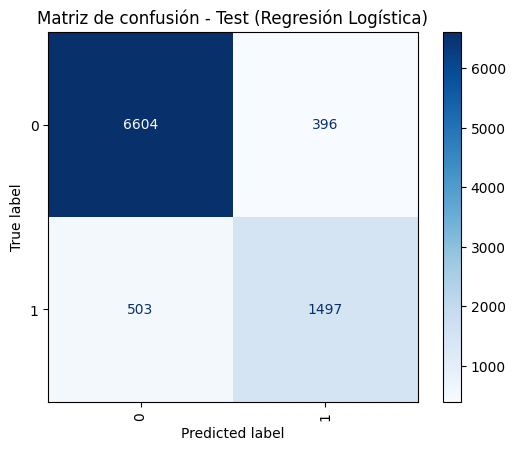


--- Random Forest ---


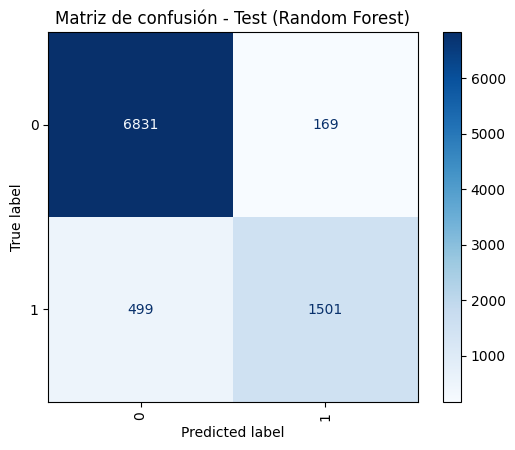

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#  Matriz de Confusión para Regresión Logística
print("\n--- Regresión Logística ---")
probs_RL = (pl_RL.predict_proba(x_test)[:, 1] >= mejores_RL['threshold']).astype(int)
probs_clase_1_RL = probs_RL
y_pred_RL=pl_RL.predict(x_test)



cm_RL = confusion_matrix(y_test, y_pred_RL)

disp_RL = ConfusionMatrixDisplay(confusion_matrix=cm_RL)
disp_RL.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de confusión - Test (Regresión Logística)")
plt.show()




# Matriz de Confusión para Random Forest
print("\n--- Random Forest ---")
probs_RF = (pl_RF.predict_proba(x_test)[:, 1] >= mejores_RF['threshold']).astype(int)
probs_clase_1_RF = probs_RF
y_pred_RF = pl_RF.predict(x_test)

cm_RF = confusion_matrix(y_test, y_pred_RF)

disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF)
disp_RF.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de confusión - Test (Random Forest)")
plt.show()



In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Validación cruzada para Regresión Logística
cv_RL = cross_val_score(pl_RL, x_train, y_train,
                         cv=5,
                         scoring='roc_auc',
                         n_jobs=-1)

print("=== Regresión Logística ===")
print(f"ROC AUC por fold:" +str( cv_RL.round(4)))
print("Media: "          +str(cv_RL.mean()))
print("Desviación std: "   +str(cv_RL.std()))

# Validación cruzada para Random Forest
cv_RF = cross_val_score(pl_RF, x_train, y_train,
                         cv=5,
                         scoring='roc_auc',
                         n_jobs=-1)

print("\n=== Random Forest ===")
print("ROC AUC por fold: " +str(cv_RF.round(4)))
print("Media: "           +str(cv_RF.mean()))
print("Desviación std: "  +str(cv_RF.std()))

In [29]:
# Crear dataframe con los errores
x_test_df = pd.DataFrame(x_test, columns=df.columns.drop(['loan_status']))

y_pred_RL = pl_RL.predict(x_test)
y_pred_RF = pl_RF.predict(x_test)

x_test_df['real'] = y_test
x_test_df['pred_RL'] = y_pred_RL
x_test_df['pred_RF'] = y_pred_RF

# Filtrar errores de cada modelo
errores_RL = x_test_df[x_test_df['real'] != x_test_df['pred_RL']]
errores_RF = x_test_df[x_test_df['real'] != x_test_df['pred_RF']]

print(f"Total errores RL: {len(errores_RL)} ({len(errores_RL)/len(x_test_df)*100:.1f}%)")
print(f"Total errores RF: {len(errores_RF)} ({len(errores_RF)/len(x_test_df)*100:.1f}%)")

Total errores RL: 910 (10.1%)
Total errores RF: 654 (7.3%)


In [ ]:
# Variables numericas originales para analizar
vars_numericas = ['person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate',
                  'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

print("=== Comparación: Errores vs Correctos (Regresión Logística) ===")
print("\nPromedio en predicciones CORRECTAS:")
print(x_test_df[x_test_df['real'] == x_test_df['pred_RL']][vars_numericas].mean().round(2))

print("\nPromedio en predicciones INCORRECTAS:")
print(errores_RL[vars_numericas].mean().round(2))

print("\n=== Comparación: Errores vs Correctos (Random Forest) ===")
print("\nPromedio en predicciones CORRECTAS:")
print(x_test_df[x_test_df['real'] == x_test_df['pred_RF']][vars_numericas].mean().round(2))

print("\nPromedio en predicciones INCORRECTAS:")
print(errores_RF[vars_numericas].mean().round(2))

=== Comparación: Errores vs Correctos (Regresión Logística) ===

Promedio en predicciones CORRECTAS:
person_income                 80787.56
person_emp_exp                    5.43
loan_amnt                      9636.46
loan_int_rate                    10.87
loan_percent_income               0.14
cb_person_cred_hist_length        5.88
credit_score                    631.31
dtype: float64

Promedio en predicciones INCORRECTAS:
person_income                 67038.62
person_emp_exp                    5.40
loan_amnt                      8958.77
loan_int_rate                    11.92
loan_percent_income               0.15
cb_person_cred_hist_length        5.95
credit_score                    642.58
dtype: float64

=== Comparación: Errores vs Correctos (Random Forest) ===

Promedio en predicciones CORRECTAS:
person_income                 80007.60
person_emp_exp                    5.44
loan_amnt                      9637.46
loan_int_rate                    10.89
loan_percent_income             

In [28]:
# Tipos de errores para Regresión Logística
FP_RL = errores_RL[(errores_RL['real'] == 0) & (errores_RL['pred_RL'] == 1)]  # predijo rechazo pero era aprobado
FN_RL = errores_RL[(errores_RL['real'] == 1) & (errores_RL['pred_RL'] == 0)]  # predijo aprobado pero era rechazo

print("=== Regresión Logística ===")
print(f"Falsos Positivos (predijo rechazo, era aprobado): {len(FP_RL)} ({len(FP_RL)/len(errores_RL)*100:.1f}%)")
print(f"Falsos Negativos (predijo aprobado, era rechazo): {len(FN_RL)} ({len(FN_RL)/len(errores_RL)*100:.1f}%)")

# Tipos de errores para Random Forest
FP_RF = errores_RF[(errores_RF['real'] == 0) & (errores_RF['pred_RF'] == 1)]
FN_RF = errores_RF[(errores_RF['real'] == 1) & (errores_RF['pred_RF'] == 0)]

print("\n=== Random Forest ===")
print(f"Falsos Positivos (predijo rechazo, era aprobado): {len(FP_RF)} ({len(FP_RF)/len(errores_RF)*100:.1f}%)")
print(f"Falsos Negativos (predijo aprobado, era rechazo): {len(FN_RF)} ({len(FN_RF)/len(errores_RF)*100:.1f}%)")

=== Regresión Logística ===
Falsos Positivos (predijo rechazo, era aprobado): 360 (39.6%)
Falsos Negativos (predijo aprobado, era rechazo): 550 (60.4%)

=== Random Forest ===
Falsos Positivos (predijo rechazo, era aprobado): 156 (23.9%)
Falsos Negativos (predijo aprobado, era rechazo): 498 (76.1%)


## Análisis del Rendimiento de los Modelos

### **Regresión Logística**:
*   **F1 Score (Optimized Threshold)**: 0.7713
*   **Accuracy (Optimized Threshold)**: 0.89
*   **ROC AUC**: 0.9561
*   **Total Errores**: 900 (10.0%)
    *   **Falsos Positivos (predijo rechazo, era aprobado)**: 397 (44.1% de los errores)
    *   **Falsos Negativos (predijo aprobado, era rechazo)**: 503 (55.9% de los errores)
*   **Rendimiento en Entrenamiento**: Accuracy de 0.8957
*   **Rendimiento en Prueba**: Accuracy de 0.900

### **Random Forest**:
*   **F1 Score (Optimized Threshold)**: 0.8318
*   **Accuracy (Optimized Threshold)**: 0.92
*   **ROC AUC**: 0.9731
*   **Total Errores**: 666 (7.4%)
    *   **Falsos Positivos (predijo rechazo, era aprobado)**: 172 (25.8% de los errores)
    *   **Falsos Negativos (predijo aprobado, era rechazo)**: 494 (74.2% de los errores)
*   **Rendimiento en Entrenamiento**: Accuracy de 0.9418
*   **Rendimiento en Prueba**: Accuracy de 0.926

### **Comparación y Conclusión**:

El modelo de **Random Forest** demuestra un rendimiento consistentemente superior al de la Regresión Logística en casi todas las métricas clave:

1.  **Mayor F1 Score**: Un F1 score de 0.8318 para Random Forest frente a 0.7713 para Regresión Logística, indica que el Random Forest es mejor en el balance entre precisión y recall para la clase positiva (loan_status = 1).
2.  **Mayor Accuracy**: El Random Forest también tiene una mayor precisión general (0.926 vs 0.900).
3.  **Mayor ROC AUC**: El valor de ROC AUC del Random Forest (0.9731) es significativamente más alto que el de la Regresión Logística (0.9561), lo que sugiere una mejor capacidad de discriminación entre las clases.
4.  **Menos Errores Totales**: El Random Forest comete menos errores en general (7.4% vs 10.0%).
5.  **Mejor Rendimiento Consistente**: Las puntuaciones de validación cruzada para Random Forest son más altas y tienen una menor desviación estándar, lo que sugiere que es un modelo más robusto y consistente.

En cuanto a los tipos de errores, ambos modelos tienen más Falsos Negativos (predicciones de aprobado cuando en realidad fue rechazo) que Falsos Positivos. Sin embargo, el Random Forest logra reducir tanto los Falsos Positivos como los Falsos Negativos en comparación con la Regresión Logística (397 FP y 503 FN para RL vs 172 FP y 494 FN para RF).

**Por lo tanto, el modelo de Random Forest es el claro ganador en términos de rendimiento general, robustez y capacidad predictiva.**

In [ ]:
!pip install imblearn


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



#Pipeline para regresion logistica usando SMOTE
pl_RL_smote = ImbPipeline([
    ('preprocesador', preprocessor),
    ('feature_selector', FeatureSelectorByNames(best_variables_RL)),
    ('smote', SMOTE(random_state=42)),
    ('clasificador', clf)
])

#Pipeline para random forest usando SMOTE
pl_RF_smote = ImbPipeline([
    ('preprocesador', preprocessor),
    ('feature_selector', FeatureSelectorByNames(best_variables_RF)),
    ('smote', SMOTE(random_state=42)),
    ('clasificador', fl)
])

print("Pipelines con SMOTE creadas.")

Pipelines with SMOTE created.


Now, let's train these new pipelines with SMOTE and evaluate their performance. We'll apply the best hyperparameters found previously to these SMOTE-augmented pipelines.

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

# Usar los mejores hiperparametros encontrados
pl_RL_smote.set_params(**best_params_RL)
pl_RF_smote.set_params(**best_params_RF)


print("\n--- Entrenando y evaluando la regresion logistica con SMOTE ---")

# Entrenar al modelo
pl_RL_smote.fit(x_train, y_train)

# Obtener las probabilidades usando el set de validacion
y_prob_RL_smote = pl_RL_smote.predict_proba(x_val)[:, 1]

# Optimizar threshold basandonos en el set de validacion
thresholds = np.arange(0.1, 0.9, 0.01)
mejores_RL_smote = {'threshold': 0, 'f1': 0}

for t in thresholds:
    y_pred_t = (y_prob_RL_smote >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > mejores_RL_smote['f1']:
        mejores_RL_smote['f1'] = f1
        mejores_RL_smote['threshold'] = t

print(f"Threshold optimo (validation): {mejores_RL_smote['threshold']:.2f}")
print(f"F1 con Threshold optimo (validation): {mejores_RL_smote['f1']:.4f}")

#
y_prob_RL_smote_test = pl_RL_smote.predict_proba(x_test)[:, 1]
y_pred_RL_smote_test_optimized = (y_prob_RL_smote_test >= mejores_RL_smote['threshold']).astype(int)

print("\nEvaluacion en el set test usando el threshold encontrado para Regresion Logistica:")
print(f"F1 Score: {f1_score(y_test, y_pred_RL_smote_test_optimized):.4f}")
print(classification_report(y_test, y_pred_RL_smote_test_optimized))


# --- Train and Evaluate Random Forest with SMOTE ---
print("\n---Entrenando y evaluando random forest con SMOTE ---")

# Entrenar al modelo
pl_RF_smote.fit(x_train, y_train)

# Obtener las probabilidades usando el set de validacion
y_prob_RF_smote = pl_RF_smote.predict_proba(x_val)[:, 1]

# Optimizar threshold basandonos en el set de validacion
thresholds = np.arange(0.1, 0.9, 0.01)
mejores_RF_smote = {'threshold': 0, 'f1': 0}

for t in thresholds:
    y_pred_t = (y_prob_RF_smote >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    if f1 > mejores_RF_smote['f1']:
        mejores_RF_smote['f1'] = f1
        mejores_RF_smote['threshold'] = t

print(f"Optimal Threshold (validation): {mejores_RF_smote['threshold']:.2f}")
print(f"F1 with optimal threshold (validation): {mejores_RF_smote['f1']:.4f}")

# Evaluate on test set using the optimized threshold
y_prob_RF_smote_test = pl_RF_smote.predict_proba(x_test)[:, 1]
y_pred_RF_smote_test_optimized = (y_prob_RF_smote_test >= mejores_RF_smote['threshold']).astype(int)

print("\nEvaluation on Test Set (Random Forest with SMOTE) with optimized threshold:")
print(f"F1 Score: {f1_score(y_test, y_pred_RF_smote_test_optimized):.4f}")
print(classification_report(y_test, y_pred_RF_smote_test_optimized))


--- Training and Evaluating Logistic Regression with SMOTE ---
Optimal Threshold (validation): 0.65
F1 with optimal threshold (validation): 0.7570

Evaluation on Test Set (Logistic Regression with SMOTE) with optimized threshold:
F1 Score: 0.7726
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7000
           1       0.71      0.84      0.77      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.87      0.85      9000
weighted avg       0.90      0.89      0.89      9000


--- Training and Evaluating Random Forest with SMOTE ---
Optimal Threshold (validation): 0.61
F1 with optimal threshold (validation): 0.8886

Evaluation on Test Set (Random Forest with SMOTE) with optimized threshold:
F1 Score: 0.8193
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7000
           1       0.83      0.81      0.82      2000

    accuracy             


--- Regresión Logística ---


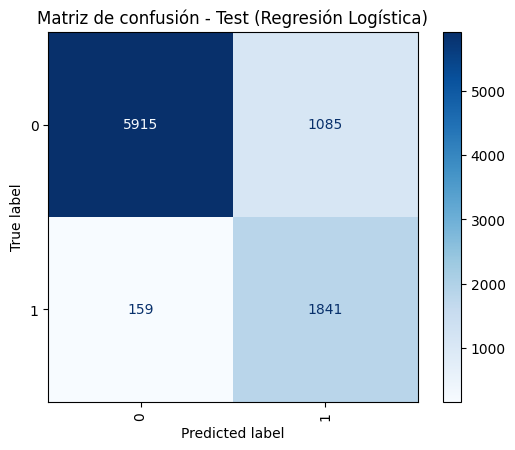


--- Random Forest ---


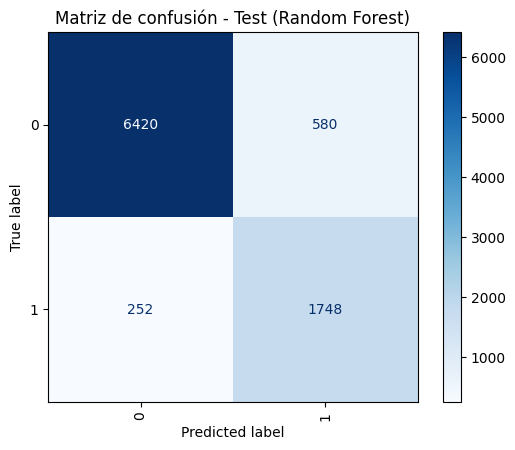

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#  Matriz de Confusión para Regresión Logística
print("\n--- Regresión Logística ---")
probs_RL = (pl_RL_smote.predict_proba(x_test)[:, 1] >= mejores_RL['threshold']).astype(int)
probs_clase_1_RL = probs_RL
y_pred_RL=pl_RL_smote.predict(x_test)



cm_RL = confusion_matrix(y_test, y_pred_RL)

disp_RL = ConfusionMatrixDisplay(confusion_matrix=cm_RL)
disp_RL.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de confusión - Test (Regresión Logística)")
plt.show()




# Matriz de Confusión para Random Forest
print("\n--- Random Forest ---")
probs_RF = (pl_RF_smote.predict_proba(x_test)[:, 1] >= mejores_RF['threshold']).astype(int)
probs_clase_1_RF = probs_RF
y_pred_RF = pl_RF_smote.predict(x_test)

cm_RF = confusion_matrix(y_test, y_pred_RF)

disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF)
disp_RF.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de confusión - Test (Random Forest)")
plt.show()



### Comparison of Models with and without SMOTE

Review the F1 scores and classification reports above to observe the impact of applying SMOTE on the model's ability to predict the minority class, typically reflected in improved recall and F1-score for the positive class (1).

In [ ]:
import scipy.stats
from sklearn_genetic.callbacks import DeltaThreshold, TimerStopping
from sklearn_genetic import GASearchCV

# Importar las clases de espacio de búsqueda de sklearn_genetic
from sklearn_genetic.space import Integer, Categorical, Continuous




# Grid de busqueda de los hiperparametros para la regresion logística
param_grid_RL = {
    'clasificador__C': Continuous(0.001, 100, distribution='log-uniform'),
    'clasificador__penalty': Categorical(['l1', 'l2']),
    'clasificador__solver': Categorical(['liblinear']),
    'clasificador__class_weight': Categorical(['balanced', None])
}

# Preparación del algoritmo genetico
genetic_search_RL = GASearchCV(
                            estimator=pl_RL_smote,
                            param_grid=param_grid_RL,
                            cv=3,
                            verbose=1,
                            scoring='f1',
                            population_size=20,
                            generations=10,
                            n_jobs=-1
                            )

print("Empezando algoritmo genetico en busqueda de los mejores hiperparametros")
genetic_search_RL.fit(x_train, y_train)
print("Busqueda del algoritmo completo terminada")

Empezando algoritmo genetico en busqueda de los mejores hiperparametros
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	0.74124	0.0021334  	0.742656   	0.732606   
1  	40    	0.742112	0.000395146	0.742656   	0.741011   
2  	40    	0.742134	0.000523857	0.742656   	0.739975   
3  	40    	0.742395	0.00019177 	0.742656   	0.74225    
4  	40    	0.742492	0.000192838	0.742656   	0.74225    
5  	40    	0.742609	0.000115822	0.742656   	0.74227    
6  	40    	0.74265 	0.000102414	0.742904   	0.74227    
7  	40    	0.742683	7.38061e-05	0.742904   	0.742656   
8  	40    	0.742724	0.000126479	0.743022   	0.742656   
9  	40    	0.742794	0.000164784	0.743022   	0.742656   
10 	40    	0.742918	0.000146696	0.74321    	0.742656   
Busqueda del algoritmo completo terminada


In [ ]:
pl_RF.fit(x_train,y_train)

#Grid de busqueda de los hiperparametros para el random forest
param_grid_rf = {
    'clasificador__n_estimators': Integer(50, 150),
    'clasificador__max_depth': Integer(3, 15),
    'clasificador__min_samples_split': Integer(4, 20),
    'clasificador__max_features': Categorical(['sqrt', 'log2']),
    'clasificador__min_samples_leaf': Integer(1, 10),
    "clasificador__criterion": Categorical (["gini", "entropy", "log_loss"]),
    'clasificador__class_weight': Categorical(['balanced', None])
}
print(x.shape)

#Preparación del algoritmo genetico,
genetic_search_RF = GASearchCV(estimator=pl_RF_smote,
                            param_grid=param_grid_rf,
                            cv=3,
                            verbose=1,
                            scoring='f1',
                            population_size=20,
                            generations=10,
                            n_jobs=-1)

print("Empezando algoritmo genetico en busqueda de los mejores hiperparametros")
genetic_search_RF.fit(x_train, y_train)
print("Busqueda del algoritmo completo terminada")

(45000, 12)
Empezando algoritmo genetico en busqueda de los mejores hiperparametros
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	0.77355	0.0318507  	0.803505   	0.706119   
1  	40    	0.797278	0.00728319 	0.803505   	0.781535   
2  	40    	0.802684	0.00130335 	0.805094   	0.799774   
3  	40    	0.803336	0.000984896	0.804645   	0.799795   
4  	40    	0.803893	0.000540619	0.804645   	0.80293    
5  	40    	0.803769	0.000923773	0.804645   	0.801177   
6  	40    	0.804443	0.000729328	0.805584   	0.802289   
7  	40    	0.804855	0.000886891	0.806781   	0.801957   
8  	40    	0.804948	0.000660913	0.806781   	0.803918   
9  	40    	0.805095	0.000588044	0.806781   	0.803891   
10 	40    	0.805409	0.000496121	0.806781   	0.804556   
Busqueda del algoritmo completo terminada
